In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = 'data_demo/caloGAN_case11_5D_120K.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

data = form_dataset(train=True)
val_data = form_dataset(train=False)
dl = torch.utils.data.DataLoader(data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)

In [3]:
for k, i in enumerate(val_loader):
    if k == 10:
        energy = i[0]
        point = i[1][0]
        momentum = i[1][1]
        print(i[0].shape)
        print(i[1][0].shape)
        print(i[1][1].shape)
        break

torch.Size([32, 1, 30, 30])
torch.Size([32, 2])
torch.Size([32, 3])


In [54]:
ticks = list(range(-20, 20 + 1, 5))
ticks

[-20, -15, -10, -5, 0, 5, 10, 15, 20]

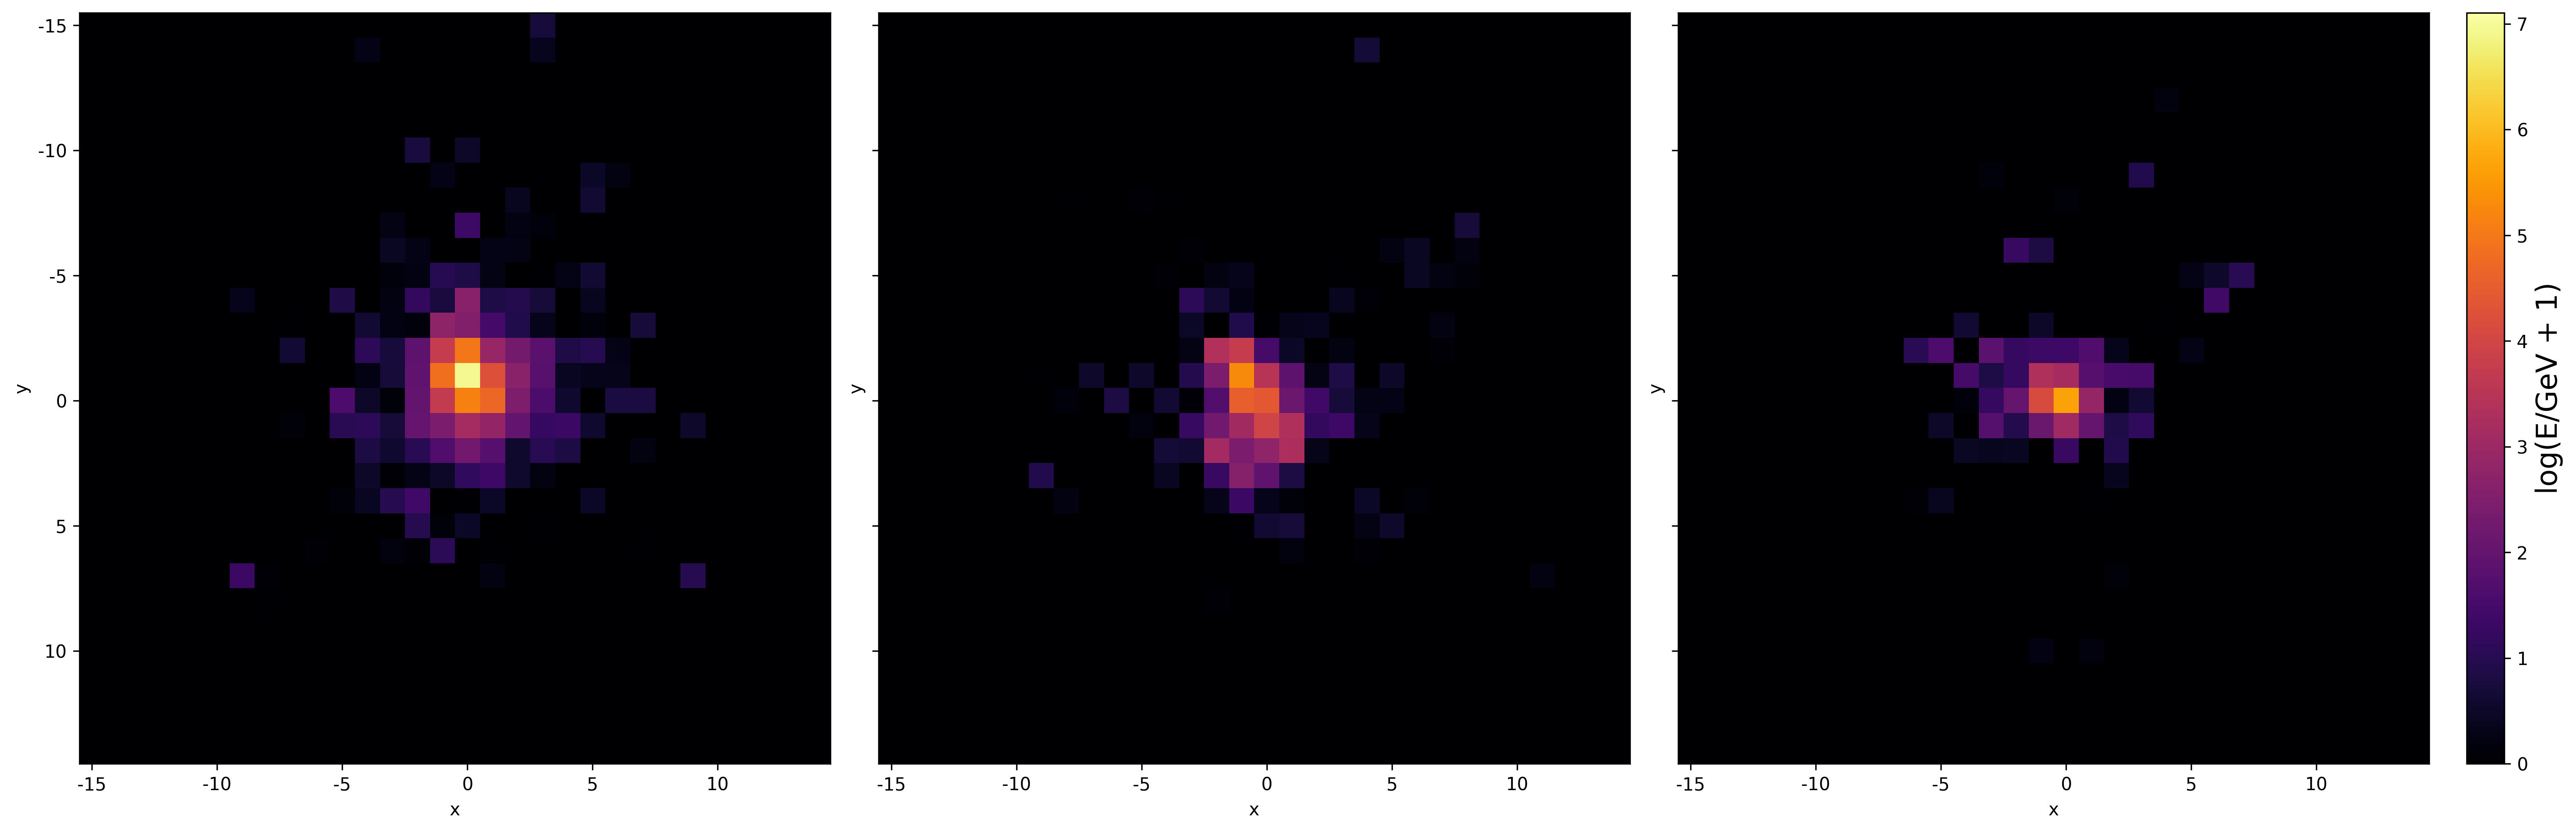

In [55]:
fig, axs = plt.subplots(1, 3, layout='constrained', sharex=True, sharey=True, dpi=300, figsize=(20, 14))
vmin, vmax = min(energy[0].min(), energy[1].min(), energy[2].min()), max(energy[0].max(), energy[1].max(), energy[2].max())
for i, k in enumerate([1, 3, 5]):
    im = axs[i].imshow(np.transpose(energy[k], (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[i].set_yticklabels(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].set_ylabel('y')
    axs[i].set_xlabel('x')
cbar = fig.colorbar(im, fraction=0.05)
cbar.set_label('log(E/GeV + 1)', size=16)
plt.show()
fig.savefig('/Users/sasaatlasov/Desktop/DiffusionDipolma/real.pdf', bbox_inches = "tight")

In [56]:
from diffusion import DiffusionModel

dm = DiffusionModel(100, 16)
dm.load_state_dict(torch.load('checkpoints/t100_cos_long.pt', map_location=torch.device('cpu')))
dm.eval();

In [57]:
# from torchview import draw_graph

# model_graph = draw_graph(dm, input_data=(energy, momentum, point), save_graph=True, filename='model')
# model_graph.visual_graph

In [58]:
# from torchsummary import summary

# summary(model, [(1, 30, 30), [3], [2], [1]])

In [59]:
with torch.no_grad():
    samples = dm.sample(momentum, point)

  0%|          | 0/99 [00:00<?, ?it/s]

In [62]:
def compare(energy, samples, idx=0, truncate=None):
    real, sampled = energy[idx].detach().numpy(), samples[idx].detach().numpy()
    vmin, vmax = min(real.min(), sampled.min()), max(real.max(), sampled.max())
    if truncate:
        sampled = np.where(sampled >= np.log1p(truncate), sampled, np.zeros_like(samples))
    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    sum1, sum2 = energy[idx].sum(), samples[idx].sum()
    im1 = axs[0].imshow(np.transpose(real, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0].set(title=f'real {sum1:.2f}')
    im2 = axs[1].imshow(np.transpose(sampled, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1].set(title=f'generated {sum2:.2f}')
    fig.colorbar(im2, fraction=0.05)
    plt.show()

In [65]:
from metrics.calogan_metrics import get_sparsity_level

In [68]:
def commm(idx=0):
    #s = np.where(samples[idx] >= np.log1p(5e-3), samples[idx], torch.zeros_like(samples[idx]))
    s = np.ma.masked_less(samples[idx], np.log1p(5e-3))
    r = np.ma.masked_less(energy[idx], np.log1p(5e-3))
    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    im1 = axs[0].imshow(np.transpose(r, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    im2 = axs[1].imshow(np.transpose(s, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    fig.colorbar(im2, fraction=0.05)
    plt.show()
    s = np.where(samples[idx] >= np.log1p(5e-3), samples[idx], torch.zeros_like(samples[idx]))
    print('Non-zero', (energy[idx] > 0).sum().item(), (s > 0).sum().item())
    print('Common', ((energy[idx] > 0) * (s > 0)).sum().item())
    print('Min', energy[idx][energy[idx] > 0].min().item(), s[s > 0].min().item())
    print('Max', energy[idx][energy[idx] > 0].max().item(), s[s > 0].max().item())
    print('Sum', energy[idx][energy[idx] > 0].sum().item(), s[s > 0].sum().item())
    print('Mean', energy[idx][energy[idx] > 0].mean().item(), s[s > 0].mean().item())
    print('Sparsity', np.mean(get_sparsity_level(r)), np.mean(get_sparsity_level(s)))
    return

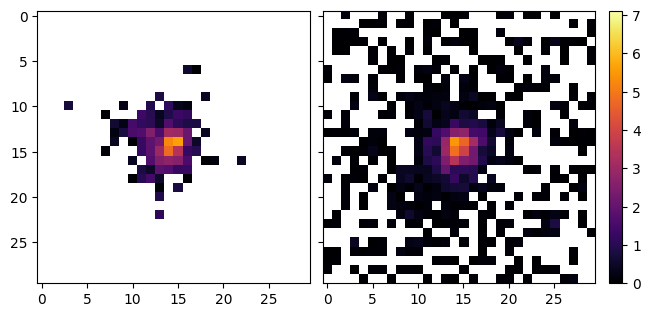

Non-zero 79 435
Common 73
Min 0.0007414573919959366 0.005079864989966154
Max 5.626787185668945 5.475098609924316
Sum 100.05238342285156 122.73704528808594
Mean 1.2664858102798462 0.2821541130542755
Sparsity 0.06166666666666666 0.22816666666666663


In [70]:
commm(0)

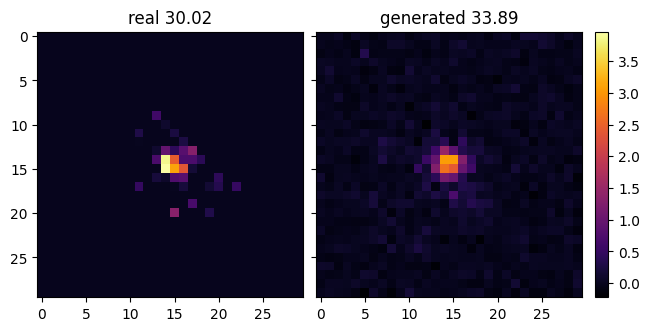

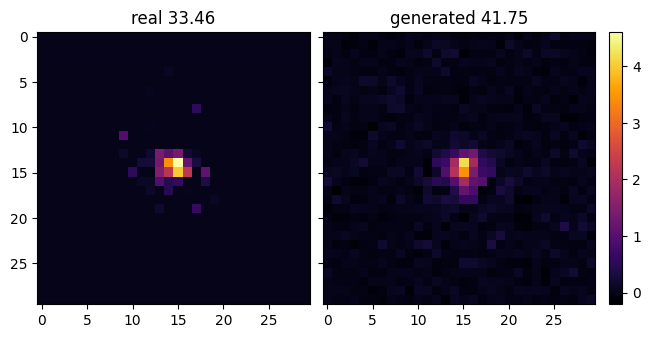

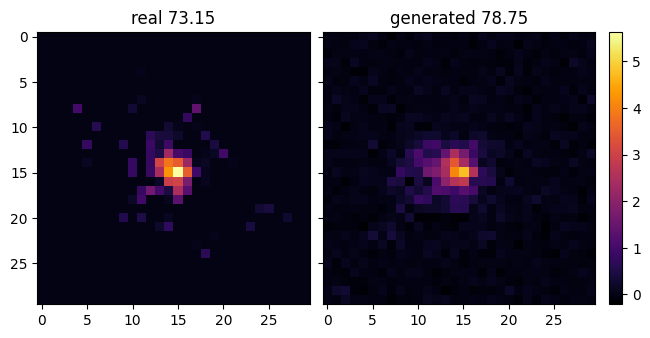

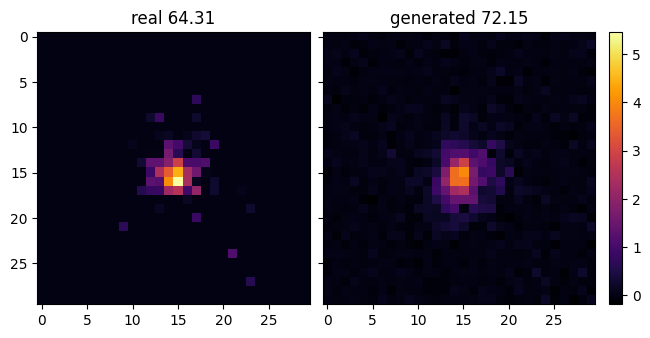

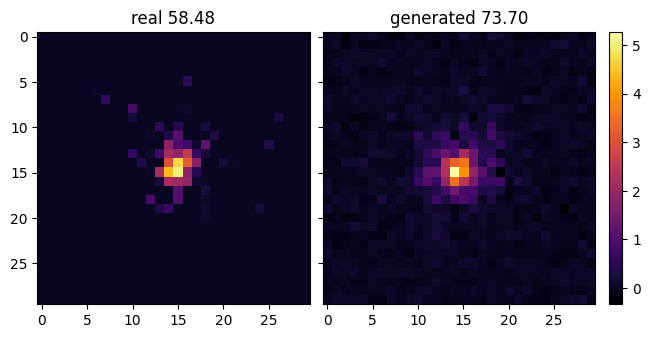

In [13]:
t = np.log1p(0)
for i in range(5):
    compare(energy, samples, idx=i)